In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews/IMDB Dataset.csv


In [2]:

import re
import nltk
from sklearn.feature_extraction.text import CountVectorizer
from collections import Counter
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer

nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /usr/share/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [3]:
df=pd.read_csv('/kaggle/input/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews/IMDB Dataset.csv')

In [4]:
df.head(3)

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive


In [5]:
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = re.sub(r'<[^>]+>', ' ', text)
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    text = text.lower()
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['clean_review'] = df['review'].apply(clean_text)

df['clean_review'] = df['clean_review'].apply(
    lambda x: ' '.join([word for word in x.split() if word not in stop_words])
)

print("Original:")
print(df['review'][0][:200])
print("\nCleaned (no stopwords):")
print(df['clean_review'][0][:200])


Original:
One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me abo

Cleaned (no stopwords):
one reviewers mentioned watching oz episode hooked right exactly happened first thing struck oz brutality unflinching scenes violence set right word go trust show faint hearted timid show pulls punche


# Bag Of Words(BOW)


**Bag of Words (BoW)** is a foundational text representation technique that converts raw text into numerical feature vectors by stripping away grammar and word order, focusing entirely on word occurrence counts. It creates a global vocabulary matrix where each row represents a document and each column represents a unique word, resulting in a highly sparse matrix filled mostly with zeros. Within this structure

In [6]:

vectorizer = CountVectorizer(max_features=5000)  


bow_matrix = vectorizer.fit_transform(df['clean_review'])

print(f"Bag of Words shape: {bow_matrix.shape}")
print(f"Vocabulary size: {len(vectorizer.get_feature_names_out())}")

Bag of Words shape: (50000, 5000)
Vocabulary size: 5000


In [7]:
feature_names = vectorizer.get_feature_names_out()

print(f"First 50 words in vocabulary:")
print(feature_names[:50])

First 50 words in vocabulary:
['aaron' 'abandoned' 'abc' 'abilities' 'ability' 'able' 'absence' 'absent'
 'absolute' 'absolutely' 'absurd' 'abuse' 'abused' 'abusive' 'abysmal'
 'academy' 'accent' 'accents' 'accept' 'acceptable' 'accepted' 'access'
 'accident' 'accidentally' 'accompanied' 'accomplished' 'according'
 'account' 'accuracy' 'accurate' 'accused' 'achieve' 'achieved'
 'achievement' 'acid' 'across' 'act' 'acted' 'acting' 'action' 'actions'
 'active' 'activities' 'actor' 'actors' 'actress' 'actresses' 'acts'
 'actual' 'actually']


In [8]:
# (first 10 reviews, ALL 5000 words)
bow_df_full = pd.DataFrame(
    bow_matrix[:10].toarray(),
    columns=feature_names
)

print("Bag of Words Matrix shape:", bow_df_full.shape)
print("\nFirst 10 reviews, first 30 columns:")
bow_df_full.iloc[:, :30]  

Bag of Words Matrix shape: (10, 5000)

First 10 reviews, first 30 columns:


,aaron,abandoned,abc,abilities,ability,able,absence,absent,absolute,absolutely,...,accepted,access,accident,accidentally,accompanied,accomplished,according,account,accuracy,accurate
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
7,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
8,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [9]:
word_counts = dict(zip(feature_names, bow_matrix.sum(axis=0).A1))


top_words = sorted(word_counts.items(), key=lambda x: x[1], reverse=True)[:20]

print("Top 20 most frequent words:")
for word, count in top_words:
    print(f"{word}: {count}")

Top 20 most frequent words:
movie: 87972
film: 79708
one: 53603
like: 40172
good: 29753
time: 25109
even: 24872
would: 24602
story: 23121
really: 23095
see: 23029
well: 21269
much: 19320
bad: 18473
get: 18422
people: 18188
great: 18145
also: 17977
first: 17583
made: 16152


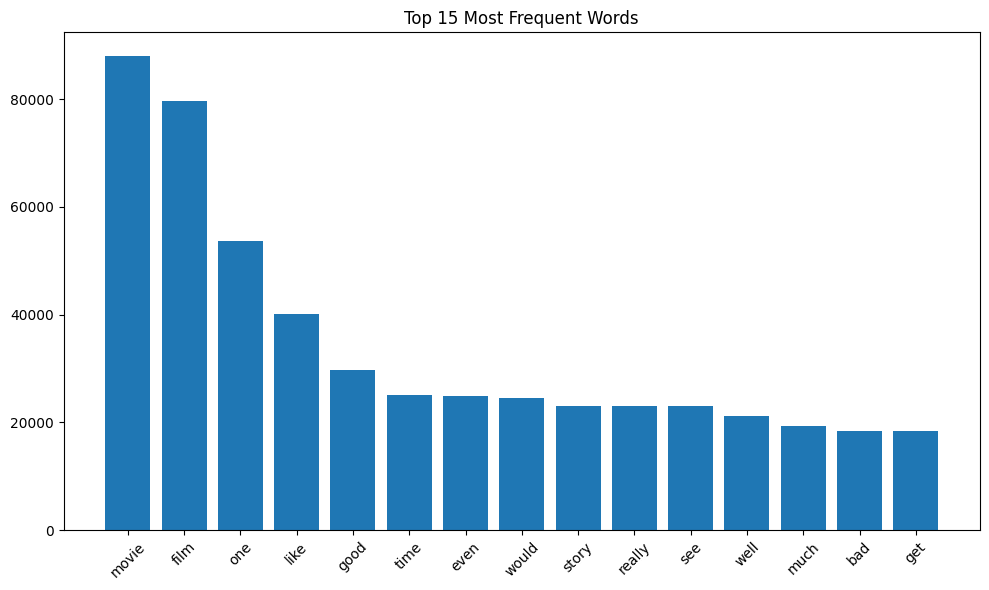

In [10]:
import matplotlib.pyplot as plt


words, counts = zip(*top_words[:15])

plt.figure(figsize=(10, 6))
plt.bar(words, counts)
plt.xticks(rotation=45)
plt.title('Top 15 Most Frequent Words')
plt.tight_layout()
plt.show()

In [11]:
df[['clean_review', 'sentiment']].head(5)

,clean_review,sentiment
0,one reviewers mentioned watching oz episode ho...,positive
1,wonderful little production filming technique ...,positive
2,thought wonderful way spend time hot summer we...,positive
3,basically family little boy jake thinks zombie...,negative
4,petter mattei love time money visually stunnin...,positive


# TF-IDF Vectorizer

**Term Frequency (TF)** measures how frequently a specific word appears within a single document, serving as an indicator of that word's importance to that local context. However, because common words naturally dominate raw counts, **Document Frequency (DF)** tracks how many documents across the entire corpus contain that word. By understanding Document Frequency, we can penalize universally common words (high DF) and give higher weight to rare, informative words (low DF) that carry actual predictive power for machine learning models.

In [12]:
tfidf_vectorizer = TfidfVectorizer(
    max_features=5000,      
    stop_words='english',   
    max_df=0.5,             
    min_df=0.001            
)

tfidf_matrix = tfidf_vectorizer.fit_transform(df['clean_review'])

print(f"TF-IDF matrix shape: {tfidf_matrix.shape}")
print(f"Vocabulary size: {len(tfidf_vectorizer.get_feature_names_out())}")


TF-IDF matrix shape: (50000, 5000)
Vocabulary size: 5000


In [13]:
feature_names = tfidf_vectorizer.get_feature_names_out()

print(f"First 50 words in TF-IDF vocabulary:")
print(feature_names[:50])

First 50 words in TF-IDF vocabulary:
['aaron' 'abandoned' 'abc' 'abilities' 'ability' 'able' 'absence' 'absent'
 'absolute' 'absolutely' 'absurd' 'abuse' 'abused' 'abusive' 'abysmal'
 'academy' 'accent' 'accents' 'accept' 'acceptable' 'accepted' 'access'
 'accident' 'accidentally' 'acclaimed' 'accompanied' 'accomplished'
 'according' 'account' 'accuracy' 'accurate' 'accurately' 'accused'
 'achieve' 'achieved' 'achievement' 'acid' 'act' 'acted' 'acting' 'action'
 'actions' 'active' 'activities' 'actor' 'actors' 'actress' 'actresses'
 'acts' 'actual']


In [14]:

doc_tfidf = tfidf_matrix[0].toarray().flatten()


top_indices = doc_tfidf.argsort()[-20:][::-1]
top_words_tfidf = [(feature_names[i], doc_tfidf[i]) for i in top_indices]

print("Top 20 words by TF-IDF score (review #0):")
for word, score in top_words_tfidf:
    print(f"{word}: {score:.4f}")

Top 20 words by TF-IDF score (review #0):
oz: 0.5697
violence: 0.2505
prison: 0.2304
forget: 0.1978
struck: 0.1778
word: 0.1255
city: 0.1243
episode: 0.1223
high: 0.1031
christians: 0.1010
guards: 0.0993
brutality: 0.0988
agenda: 0.0974
experimental: 0.0964
away: 0.0956
painted: 0.0934
darker: 0.0930
hardcore: 0.0925
right: 0.0917
comfortable: 0.0917


In [15]:
from sklearn.feature_extraction.text import CountVectorizer


bow_vectorizer = CountVectorizer(max_features=5000, stop_words='english')
bow_matrix = bow_vectorizer.fit_transform(df['clean_review'])


bow_scores = bow_matrix[0].toarray().flatten()
top_bow_indices = bow_scores.argsort()[-20:][::-1]
top_words_bow = [(bow_vectorizer.get_feature_names_out()[i], bow_scores[i]) for i in top_bow_indices]

print("="*60)
print("BAG OF WORDS (top 10):")
for word, score in top_words_bow[:10]:
    print(f"{word}: {score}")

print("\n" + "="*60)
print("TF-IDF (top 10):")
for word, score in top_words_tfidf[:10]:
    print(f"{word}: {score:.4f}")

BAG OF WORDS (top 10):
oz: 6
violence: 4
prison: 3
forget: 3
word: 2
away: 2
struck: 2
city: 2
high: 2
right: 2

TF-IDF (top 10):
oz: 0.5697
violence: 0.2505
prison: 0.2304
forget: 0.1978
struck: 0.1778
word: 0.1255
city: 0.1243
episode: 0.1223
high: 0.1031
christians: 0.1010


In [16]:

avg_tfidf = tfidf_matrix.mean(axis=0).A1


top_avg_indices = avg_tfidf.argsort()[-20:][::-1]
top_avg_words = [(feature_names[i], avg_tfidf[i]) for i in top_avg_indices]

print("Top 20 words by average TF-IDF (most distinctive across all reviews):")
for word, score in top_avg_words:
    print(f"{word}: {score:.4f}")

Top 20 words by average TF-IDF (most distinctive across all reviews):
like: 0.0293
good: 0.0260
really: 0.0219
time: 0.0216
story: 0.0216
bad: 0.0206
great: 0.0195
people: 0.0180
movies: 0.0178
watch: 0.0166
think: 0.0158
make: 0.0158
seen: 0.0157
acting: 0.0154
characters: 0.0154
way: 0.0153
love: 0.0150
plot: 0.0149
films: 0.0146
best: 0.0141


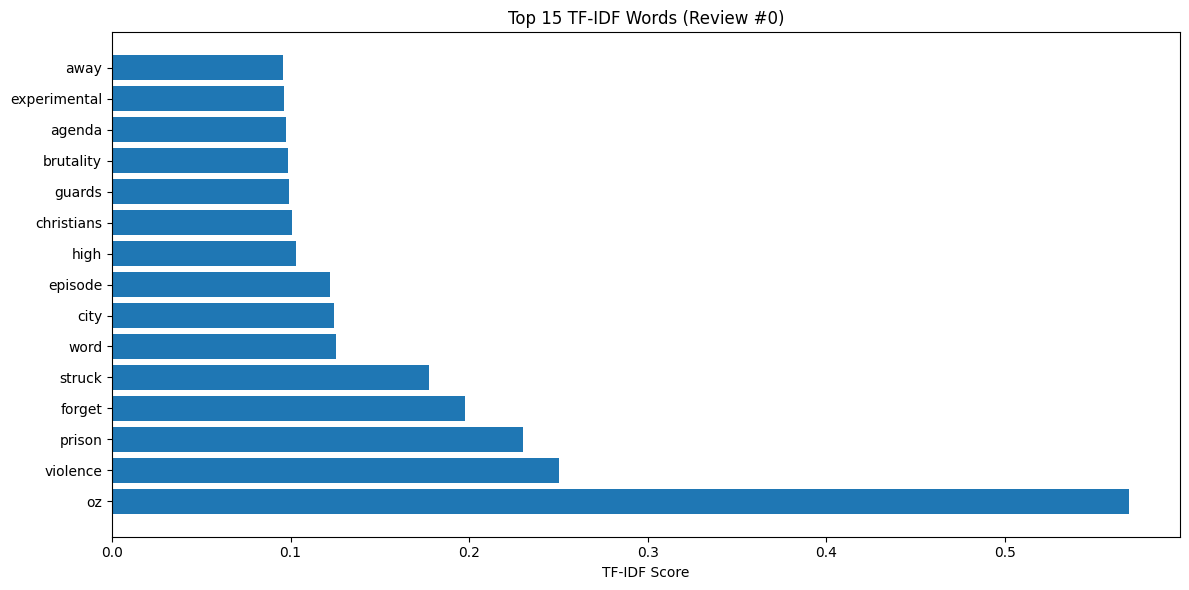

In [17]:
import matplotlib.pyplot as plt

words, scores = zip(*top_words_tfidf[:15])

plt.figure(figsize=(12, 6))
plt.barh(words, scores)
plt.yticks(rotation=0)
plt.xlabel('TF-IDF Score')
plt.title('Top 15 TF-IDF Words (Review #0)')
plt.tight_layout()
plt.show()

# N-Grams 

 ***Understanding N-Grams***

An **N-gram** is a contiguous sequence of **N** tokens (words) from a given sample of text. It allows our models to capture word order and local context rather than treating every word completely in isolation.

*   **UNIGRAM (N=1):** Single, individual words (e.g., `movie`, `good`, `bad`). They count occurrences but lose all context and sentence structure.
*   **BIGRAM (N=2):** Two-word phrases (e.g., `good movie`, `not good`). Bigrams are highly valuable because they catch simple modifications and negations.
*   **TRIGRAM (N=3):** Three-word phrases (e.g., `not a masterpiece`, `waste of time`). They capture complex sentiments but increase data sparsity.

***The Context Trap: Why N-Grams Matter***
If your model only looks at **Unigrams**, the phrase **"not good"** gets split into **"not"** and **"good"**. The model might see **"good"** and mistakenly classify the review as positive. By combining **Unigrams + Bigrams**, the model captures the exact phrase **"not good"** as a single feature, maintaining the true negative sentiment.


## Unigram

In [18]:

unigram_vectorizer = CountVectorizer(ngram_range=(1, 1), max_features=20)
unigram_matrix = unigram_vectorizer.fit_transform(df['clean_review'])

unigram_names = unigram_vectorizer.get_feature_names_out()
unigram_counts = dict(zip(unigram_names, unigram_matrix.sum(axis=0).A1))
top_unigrams = sorted(unigram_counts.items(), key=lambda x: x[1], reverse=True)[:20]

print("TOP 20 UNIGRAMS (single words):")
for word, count in top_unigrams:
    print(f"{word}: {count}")

TOP 20 UNIGRAMS (single words):
movie: 87972
film: 79708
one: 53603
like: 40172
good: 29753
time: 25109
even: 24872
would: 24602
story: 23121
really: 23095
see: 23029
well: 21269
much: 19320
bad: 18473
get: 18422
people: 18188
great: 18145
also: 17977
first: 17583
made: 16152


## Bigram

In [19]:

bigram_vectorizer = CountVectorizer(ngram_range=(2, 2), max_features=20)
bigram_matrix = bigram_vectorizer.fit_transform(df['clean_review'])


bigram_names = bigram_vectorizer.get_feature_names_out()
bigram_counts = dict(zip(bigram_names, bigram_matrix.sum(axis=0).A1))
top_bigrams = sorted(bigram_counts.items(), key=lambda x: x[1], reverse=True)[:20]

print("\nTOP 20 BIGRAMS (2-word phrases):")
for phrase, count in top_bigrams:
    print(f"{phrase}: {count}")


TOP 20 BIGRAMS (2-word phrases):
ever seen: 2710
special effects: 2249
even though: 1999
one best: 1913
low budget: 1823
looks like: 1642
year old: 1601
waste time: 1509
see movie: 1502
much better: 1497
good movie: 1442
first time: 1416
sci fi: 1393
watch movie: 1318
new york: 1317
look like: 1276
years ago: 1256
real life: 1238
movie ever: 1234
high school: 1164


In [20]:
# Combined unigrams + bigrams
combined_vectorizer = CountVectorizer(ngram_range=(1, 2), max_features=50)
combined_matrix = combined_vectorizer.fit_transform(df['clean_review'])


combined_names = combined_vectorizer.get_feature_names_out()
combined_counts = dict(zip(combined_names, combined_matrix.sum(axis=0).A1))
top_combined = sorted(combined_counts.items(), key=lambda x: x[1], reverse=True)[:25]

print("\nTOP 25 COMBINED (unigrams + bigrams):")
for item, count in top_combined[:30]:
    print(f"{item}: {count}")


TOP 25 COMBINED (unigrams + bigrams):
movie: 87972
film: 79708
one: 53603
like: 40172
good: 29753
time: 25109
even: 24872
would: 24602
story: 23121
really: 23095
see: 23029
well: 21269
much: 19320
bad: 18473
get: 18422
people: 18188
great: 18145
also: 17977
first: 17583
made: 16152
make: 15898
way: 15645
could: 15565
movies: 15309
characters: 14456


***The list currently shows only unigrams. If bigrams like good movie or waste time were included, they would appear further down the list because two-word combinations naturally have lower frequencies than single words.***

In [21]:
# Tokenize first review
from nltk.tokenize import word_tokenize

text = df['clean_review'][0]
words = word_tokenize(text)

print(f"First 20 words (unigrams): {words[:20]}")
print(f"\nFirst 10 bigrams:")
for i in range(min(10, len(words)-1)):
    print(f"{words[i]} {words[i+1]}")

First 20 words (unigrams): ['one', 'reviewers', 'mentioned', 'watching', 'oz', 'episode', 'hooked', 'right', 'exactly', 'happened', 'first', 'thing', 'struck', 'oz', 'brutality', 'unflinching', 'scenes', 'violence', 'set', 'right']

First 10 bigrams:
one reviewers
reviewers mentioned
mentioned watching
watching oz
oz episode
episode hooked
hooked right
right exactly
exactly happened
happened first
